# Analysis

## Loading data

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [2]:
#### SET PATHS
os.chdir('..')
mainpath = os.getcwd()
datapath = os.path.join(mainpath, 'Data')
respath  = os.path.join(mainpath, 'Results')

In [3]:
# New variables names
os.chdir(datapath)
var_newnames = pd.read_csv('Phenotype_categories.csv').set_index('var')
var_newnames = var_newnames['newvar'].to_dict()

# Variable description
os.chdir(os.path.join(datapath, 'nh_99-06'))
var_description = pd.read_csv('VarDescription.csv')\
                     .drop_duplicates()\
                     .set_index('var')

# Cleaned raw data
os.chdir(respath)
loadfiles = ['Discovery_Females', 'Discovery_Males', 'Replication_Females', 'Replication_Males']
dfs = []
for i in range(4):
    dfs.append(pd.read_csv('CleanData_' + loadfiles[i] + '.csv').set_index('ID'))

# Result data
nhanes_res = pd.read_csv('Difference_test.csv').rename(columns={'pvalue_difference':'pvalue'}).set_index(['Variable','Phenotype'])

# Convert variable descriptions to a dictionary for convenience
var_descr_dict = var_description['var_desc'].to_dict()
var_category   = var_description['category'].to_dict()

phenotype = ["LBXSCRINV","URXUCR","LBXSCR","LBXSATSI","LBXSAL","URXUMASI","URXUMA","LBXSAPSI","LBXSASSI","LBXSC3SI",
             "LBXSBU","LBXBAP","LBXCPSI","LBXCRP","LBXSCLSI","LBXSCH","LBDHDL","LBDLDL","LBXSGTSI","LBXSGB",
             "LBXGLU","LBXGH","LBXHCY","LBXSIR","LBXSLDSI","LBXMMA","LBXSOSSI","LBXSPH","LBXSKSI",	
             "LBXSNASI","LBXSTB","LBXSCA","LBXSTP","LBXSTR","LBXSUA","LBDBANO","LBXBAPCT",
             "LBDEONO","LBXEOPCT","LBXHCT","LBXHGB","LBDLYMNO","LBXMCHSI","LBXLYPCT","LBXMCVSI","LBXMPSI","LBDMONO",
             "LBXMOPCT","LBXPLTSI","LBXRBCSI","LBXRDW","LBDNENO","LBXNEPCT"] # I removed the ones that were deleted in the QC process

covariates = ["black", "mexican", "other_hispanic", "other_eth", "SES_LEVEL", "RIDAGEYR", "SDDSRVYR","BMXBMI"]

cols = list(dfs[0].columns)
ind  = list(var_description.index)
keep_vars = [ind.index(cols[x]) for x in range(len(cols)) if cols[x] in ind]
counts    = var_description.iloc[keep_vars, 34].value_counts(sort=True) #34 is the category position

In [4]:
counts

food component recall    76
biochemistry             38
pcbs                     35
blood                    20
volatile compounds       19
hydrocarbons             18
body measures            17
supplement use           16
nutrients                15
heavy metals             14
smoking behavior         13
pesticides               13
phthalates               12
furans                   10
disease                   7
dioxins                   7
phytoestrogens            6
diakyl                    6
bacterial infection       5
viral infection           5
alcohol use               4
occupation                4
blood pressure            3
housing                   3
smoking family            2
hormone                   2
social support            2
immunization              1
cotinine                  1
Name: category, dtype: int64

In [7]:
import scipy.cluster.hierarchy as sch

def estimate_corr(dat):
    """
    Generate correlation and outputs a numpy array with zeros in the diagonal
    """
    corr = dat.corr(method='spearman')
    corr = np.array(corr)
    np.fill_diagonal(corr, 0)
    return(corr)

def cluster_corr(corr_array, inplace=False, returnindex=False):
    """
    Rearranges the correlation matrix, corr_array, so that groups of highly 
    correlated variables are next to each other 
    
    Parameters
    ----------
    corr_array : pandas.DataFrame or numpy.ndarray
        a NxN correlation matrix 
        
    Returns
    -------
    pandas.DataFrame or numpy.ndarray
        a NxN correlation matrix with the columns and rows rearranged
    """
    pairwise_distances = sch.distance.pdist(corr_array)
    linkage = sch.linkage(pairwise_distances, method='complete')
    cluster_distance_threshold = pairwise_distances.max()/2
    idx_to_cluster_array = sch.fcluster(linkage, cluster_distance_threshold, 
                                        criterion='distance')
    idx = np.argsort(idx_to_cluster_array)
    
    if returnindex:
        return idx
    else:
        if not inplace:
            corr_array = corr_array.copy()
        
        if isinstance(corr_array, pd.DataFrame):
            return corr_array.iloc[idx, :].T.iloc[idx, :]
        return corr_array[idx, :][:, idx]

In [192]:
# Order variables based on categories
ordered_vars = list(var_description.iloc[keep_vars, 34].sort_values().index)
ispheno      = pd.Series(ordered_vars).isin(phenotype)

In [106]:
corr_matrix_males   = nhanes_males[ordered_vars].corr(method='spearman')
corr_matrix_females = nhanes_females[ordered_vars].corr(method='spearman')

In [107]:
corr_matrix_females = np.array(corr_matrix_females)
corr_matrix_males   = np.array(corr_matrix_males)

In [108]:
np.fill_diagonal(corr_matrix_females, 0)
np.fill_diagonal(corr_matrix_males, 0)

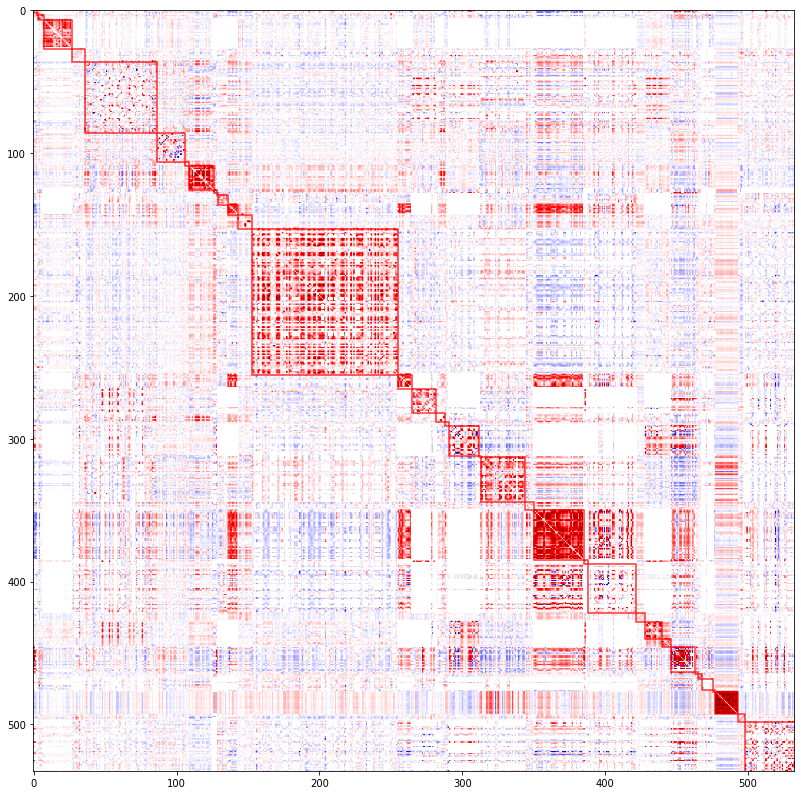

In [143]:
fig = plt.figure(figsize=(14,14))
ax  = fig.add_subplot(111)
im =  ax.imshow(corr_matrix_males, cmap='coolwarm')
start = 0
for i,l in enumerate(counts.sort_index()):
    end = l
    ax.add_patch(patches.Rectangle((start, start), end, end, alpha=0.8, fill=False, facecolor="red", edgecolor="red", linewidth=1.5, linestyle='solid'))
    start = start + end

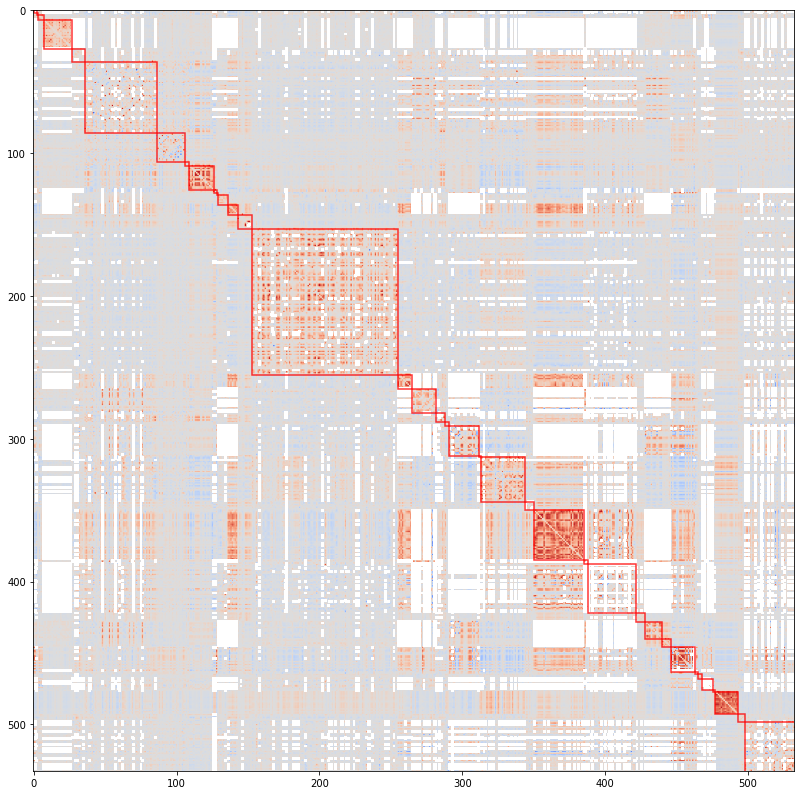

In [210]:
fig = plt.figure(figsize=(14,14))
ax  = fig.add_subplot(111)
im =  ax.imshow(corr_matrix_females, cmap='coolwarm')
start = 0
for i,l in enumerate(counts.sort_index()):
    end = l
    ax.add_patch(patches.Rectangle((start, start), end, end, alpha=0.8, fill=False, facecolor="red", edgecolor="red", linewidth=1.5, linestyle='solid'))
    start = start + end

In [235]:
import scipy.cluster.hierarchy as sch

def cluster_corr(corr_array, inplace=False, returnindex=False):
    """
    Rearranges the correlation matrix, corr_array, so that groups of highly 
    correlated variables are next to eachother 
    
    Parameters
    ----------
    corr_array : pandas.DataFrame or numpy.ndarray
        a NxN correlation matrix 
        
    Returns
    -------
    pandas.DataFrame or numpy.ndarray
        a NxN correlation matrix with the columns and rows rearranged
    """
    pairwise_distances = sch.distance.pdist(corr_array)
    linkage = sch.linkage(pairwise_distances, method='complete')
    cluster_distance_threshold = pairwise_distances.max()/2
    idx_to_cluster_array = sch.fcluster(linkage, cluster_distance_threshold, 
                                        criterion='distance')
    idx = np.argsort(idx_to_cluster_array)
    
    if returnindex:
        return idx
    else:
        if not inplace:
            corr_array = corr_array.copy()
        
        if isinstance(corr_array, pd.DataFrame):
            return corr_array.iloc[idx, :].T.iloc[idx, :]
        return corr_array[idx, :][:, idx]

In [236]:
new_corr_males   = cluster_corr(pd.DataFrame(corr_matrix_males).loc[ispheno, ispheno])
new_corr_females = cluster_corr(pd.DataFrame(corr_matrix_females).loc[ispheno, ispheno])

In [239]:
filtered_list = [i for indx,i in enumerate(ordered_vars) if ispheno[indx] == True]
idx_males     = cluster_corr(pd.DataFrame(corr_matrix_males).loc[ispheno, ispheno], returnindex=True)
idx_females   = cluster_corr(pd.DataFrame(corr_matrix_females).loc[ispheno, ispheno], returnindex=True)

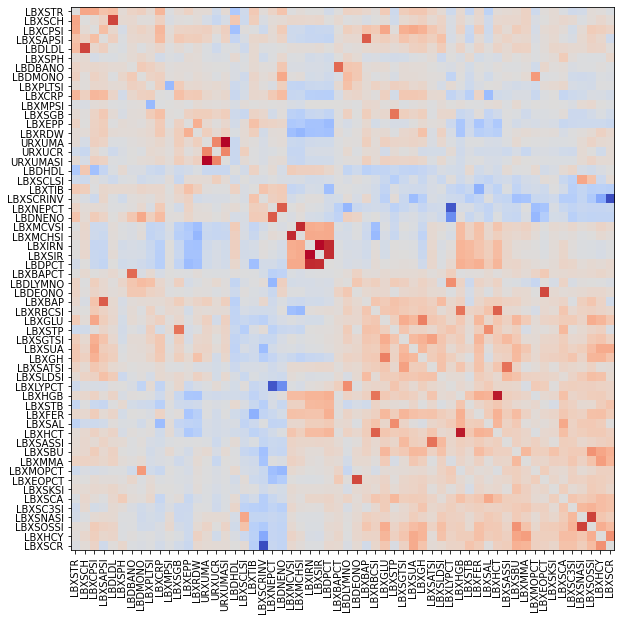

In [245]:
fig = plt.figure(figsize=(10,10))
ax  = fig.add_subplot(111)
im =  ax.imshow(pd.DataFrame(new_corr_females).loc[ispheno, ispheno], cmap='coolwarm')
var_names_females = [filtered_list[i] for i in idx_females]
plt.xticks(range(len(var_names_females)), var_names_females, rotation=90);
plt.yticks(range(len(var_names_females)), var_names_females);

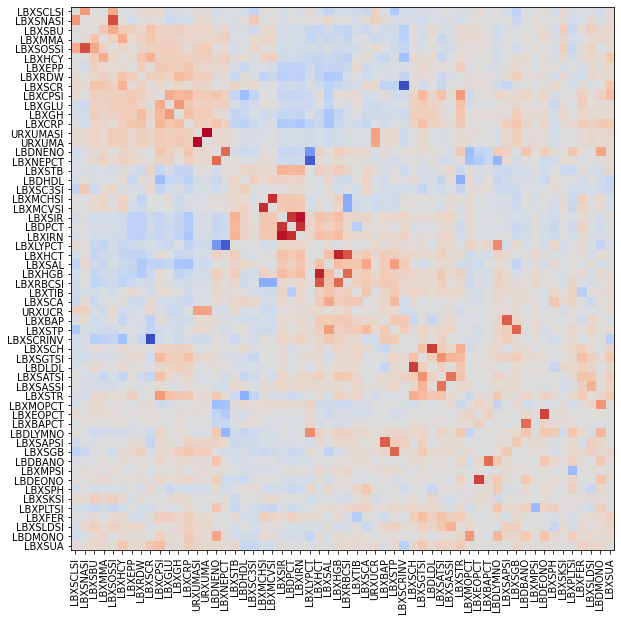

In [246]:
fig = plt.figure(figsize=(10,10))
ax  = fig.add_subplot(111)
im =  ax.imshow(pd.DataFrame(new_corr_males).loc[ispheno, ispheno], cmap='coolwarm')
var_names_males = [filtered_list[i] for i in idx_males]
plt.xticks(range(len(var_names_males)), var_names_males, rotation=90);
plt.yticks(range(len(var_names_males)), var_names_males);